In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow shap streamlit


Active code page: 1252
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!python -m pip install --upgrade pip


Active code page: 1252


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\satya\DON_Prediction\data\MLE-Assignment.csv")

# Basic info
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 450 entries, hsi_id to vomitoxin_ppb
dtypes: float64(449), object(1)
memory usage: 1.7+ MB
None


,hsi_id,0,1,2,3,4,5,6,7,8,...,439,440,441,442,443,444,445,446,447,vomitoxin_ppb
0,imagoai_corn_0,0.416181,0.396844,0.408985,0.372865,0.385293,0.365390,0.355226,0.343350,0.344837,...,0.710280,0.717482,0.715078,0.705379,0.696691,0.692793,0.711369,0.697679,0.704520,1100.0
1,imagoai_corn_1,0.415797,0.402956,0.402564,0.396014,0.397192,0.389634,0.375671,0.363689,0.373883,...,0.684011,0.697271,0.701995,0.696077,0.701012,0.677418,0.696921,0.696544,0.689054,1000.0
2,imagoai_corn_2,0.389023,0.371206,0.373098,0.373872,0.361056,0.349709,0.333882,0.330841,0.328925,...,0.683054,0.669286,0.663179,0.676165,0.676591,0.655951,0.658945,0.670989,0.665176,1300.0
3,imagoai_corn_3,0.468837,0.473255,0.462949,0.459335,0.461672,0.459824,0.458194,0.427737,0.415360,...,0.742782,0.730801,0.736787,0.730044,0.751437,0.738497,0.742446,0.754657,0.733474,1300.0
4,imagoai_corn_4,0.483352,0.487274,0.469153,0.487648,0.464026,0.451152,0.458229,0.440782,0.426193,...,0.770227,0.773013,0.761431,0.763488,0.762473,0.744012,0.775486,0.760431,0.751988,220.0


hsi_id           0
0                0
1                0
2                0
3                0
                ..
444              0
445              0
446              0
447              0
vomitoxin_ppb    0
Length: 450, dtype: int64
                0           1           2           3           4           5  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.443118    0.440761    0.433814    0.426122    0.418990    0.412432   
std      0.044719    0.045520    0.045764    0.046070    0.045405    0.044727   
min      0.311182    0.295321    0.284064    0.282054    0.296702    0.286860   
25%      0.410456    0.404310    0.397038    0.389029    0.382102    0.377157   
50%      0.449105    0.442651    0.434215    0.425074    0.417075    0.411872   
75%      0.480245    0.478822    0.473158    0.464947    0.459232    0.452198   
max      0.556287    0.530168    0.528774    0.533202    0.511909    0.501786   

                6           7      

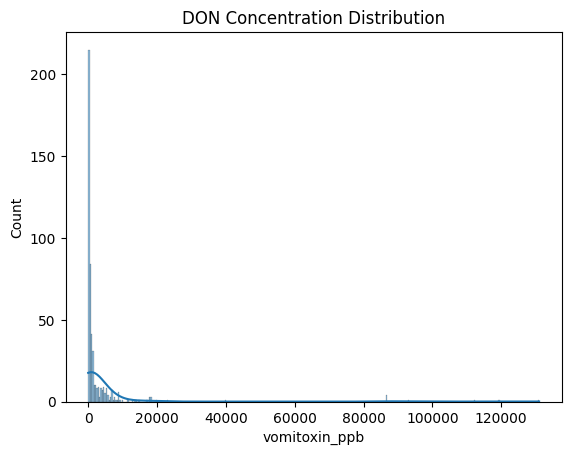

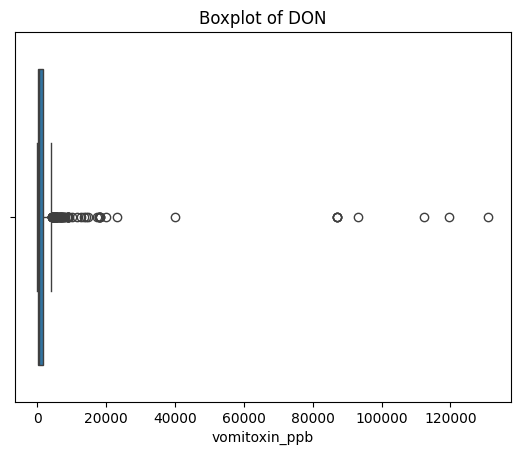

In [6]:
# Check for missing values
print(df.isnull().sum())

# Summary
print(df.describe())

# Visualize DON distribution
sns.histplot(df['vomitoxin_ppb'], kde=True)
plt.title('DON Concentration Distribution')
plt.show()

# Boxplot to detect outliers
sns.boxplot(x=df['vomitoxin_ppb'])
plt.title('Boxplot of DON')
plt.show()


In [8]:
# Add this at the top to make 'src' module accessible
import sys
import os

# Set project root one level up from /notebooks/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Standard imports
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from src.data_processing import preprocess_data

# Load dataset
df = pd.read_csv(os.path.join(project_root, 'data', 'MLE-Assignment.csv'))

# Preprocess data
X, y, scaler = preprocess_data(df)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Save model to models/ folder
model_dir = os.path.join(project_root, 'models')
os.makedirs(model_dir, exist_ok=True)
model.save(os.path.join(model_dir, 'don_model.h5'))

print("✅ Model saved as models/don_model.h5")


C:\Users\satya\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 119017872.0000 - mae: 2864.1177 - val_loss: 298959968.0000 - val_mae: 4408.2754
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 174027184.0000 - mae: 3381.8711 - val_loss: 298857504.0000 - val_mae: 4398.7168
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 120479320.0000 - mae: 3118.3296 - val_loss: 298654432.0000 - val_mae: 4379.6958
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 215524032.0000 - mae: 3461.9487 - val_loss: 298288160.0000 - val_mae: 4347.6201
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 154774256.0000 - mae: 3148.4395 - val_loss: 297698720.0000 - val_mae: 4304.2100
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 178101664.0000 - mae: 3361.4712 - val_loss: 296851840.0000 - val_mae: 4270.6621
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 160083472.0000 - mae: 3239.2449 - val_loss: 295720768.0000 - val_mae: 4269.8955
Epoch 8/50
13/13 ━━━━━━━━━━

✅ Model saved as models/don_model.h5


In [10]:
print(df.columns)


Index(['hsi_id', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '439', '440', '441', '442', '443', '444', '445', '446', '447',
       'vomitoxin_ppb'],
      dtype='object', length=450)
